In [32]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import hmean

sns.set_style("whitegrid")
pd.set_option("display.float_format", "{:.4f}".format)

data_list = []
for filename in os.listdir("results_geg_rq5"):
    if filename.endswith(".csv"):
        dataset = filename.split("_")[0]
        df = pd.read_csv(os.path.join("results_geg_rq5", filename))
        df["dataset"] = dataset
        data_list.append(df)
data = pd.concat(data_list, ignore_index=True)

In [33]:
data = data.drop(columns=['statistical_parity', 'equal_opportunity', 'average_odds'])

In [34]:
data[["wc_statistical_parity", "wc_equal_opportunity", "wc_average_odds"]] = data[
    ["wc_statistical_parity", "wc_equal_opportunity", "wc_average_odds"]
].abs()

In [35]:
data['harmonic_mean'] = data.apply(
    lambda row: hmean([row['accuracy'], row['f1_score'], 1 - row['wc_statistical_parity'], 1 - row['wc_equal_opportunity'], 1 - row['wc_average_odds']]),
    axis=1)

In [36]:
data

,fold,accuracy,precision,recall,f1_score,wc_statistical_parity,wc_equal_opportunity,wc_average_odds,constraint,difference_bound,dataset,harmonic_mean
0,1,0.6014,0.5699,0.5506,0.5343,0.0424,0.2500,0.0848,dp,0.0000,cmc,0.7138
1,2,0.6149,0.6062,0.5678,0.5494,0.0468,0.1508,0.0518,dp,0.0000,cmc,0.7432
2,3,0.5608,0.5108,0.5106,0.5050,0.0420,0.1180,0.0787,dp,0.0000,cmc,0.7116
3,4,0.5782,0.6357,0.5436,0.5191,0.0264,0.1088,0.1079,dp,0.0000,cmc,0.7219
4,5,0.6259,0.5895,0.5522,0.5558,0.0258,0.2353,0.1434,dp,0.0000,cmc,0.7248
...,...,...,...,...,...,...,...,...,...,...,...,...
4195,6,0.6543,0.6226,0.6029,0.6044,0.1345,0.2789,0.1679,eo,0.0950,drug,0.7218
4196,7,0.6968,0.5701,0.6055,0.5693,0.3072,0.4500,0.2864,eo,0.0950,drug,0.6366
4197,8,0.6915,0.6202,0.6024,0.6069,0.1773,0.4000,0.2317,eo,0.0950,drug,0.6870
4198,9,0.6436,0.5865,0.5986,0.5880,0.0334,0.1531,0.0530,eo,0.0950,drug,0.7662


In [37]:
data['constraint'] = data['constraint'].replace({
    'dp': 'GEG-SP',
    'eo': 'GEG-EO',
    'cp': 'GEG-CP',
})

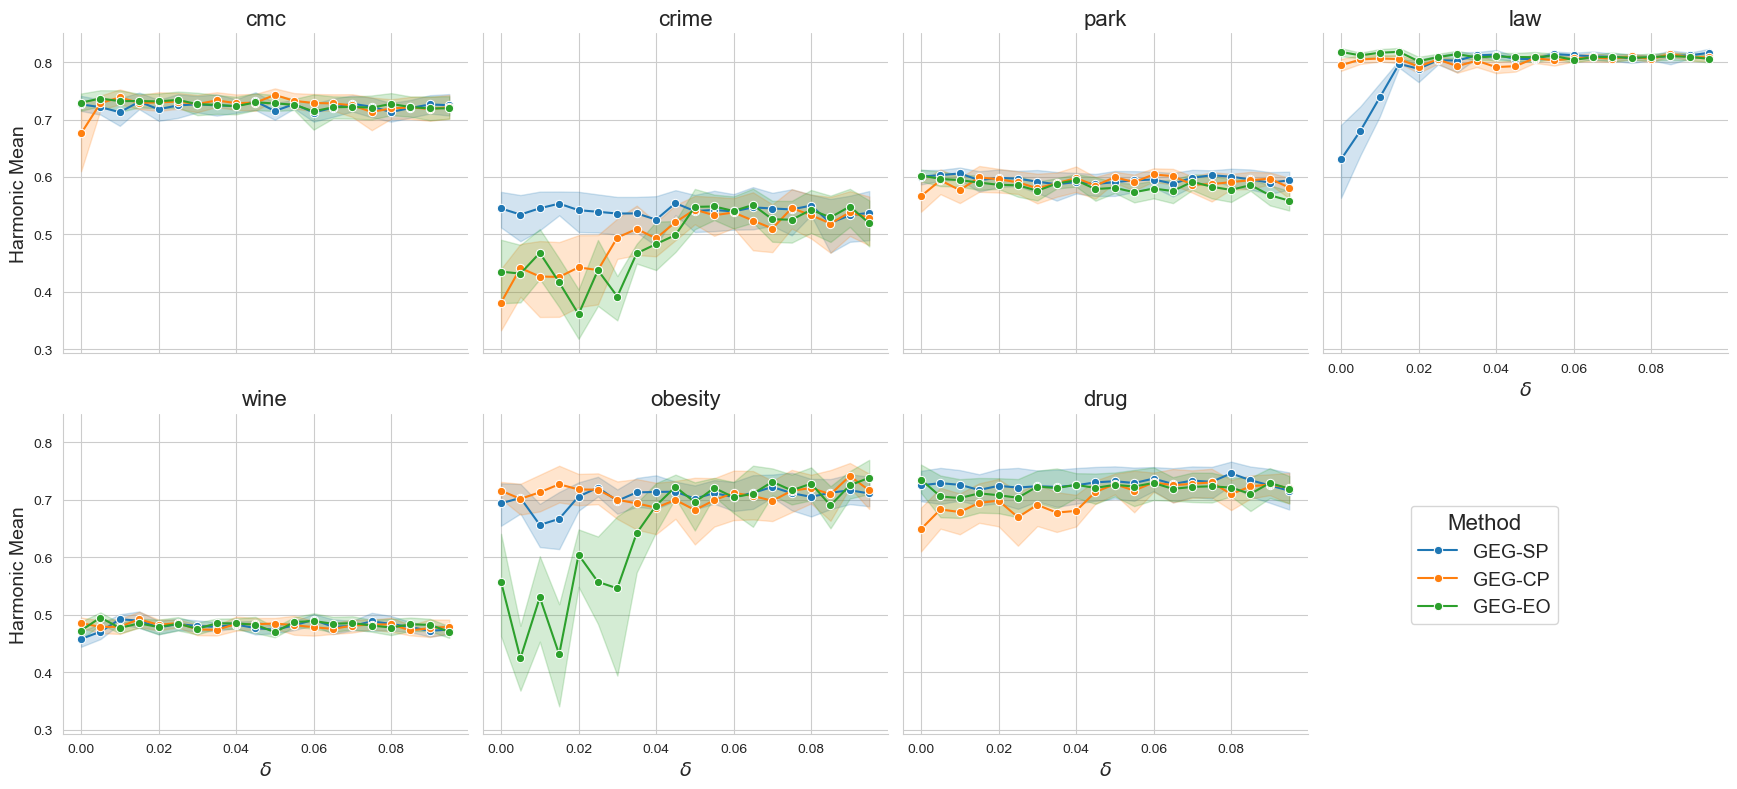

In [38]:
g = sns.FacetGrid(data, col="dataset", col_wrap=4, height=4)
g.map_dataframe(sns.lineplot, y="harmonic_mean", x="difference_bound", hue="constraint", marker="o")
g.set_axis_labels("$\\delta$", "Harmonic Mean", size=14)
g.set_titles(col_template="{col_name}", size=16)
g.add_legend(
    title="Constraint", loc="lower right", prop={"size": 14}, bbox_to_anchor=(0.9, 0.2),frameon=True)
# position the legend near the last plot
# sns.move_legend(g, "lower right", bbox_to_anchor=(0.9, 0.2))
g.legend.set_title("Method", prop={"size": 16})
plt.tight_layout()
plt.savefig("imgs/harmonic_mean_rq5.pdf", bbox_inches="tight")
plt.show()

## Ratio bound slack sensitivity analysis

In [39]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import hmean

sns.set_style("whitegrid")
pd.set_option("display.float_format", "{:.4f}".format)

data_list = []
for filename in os.listdir("results_geg_rq5_ratio_bound_slack"):
    if filename.endswith(".csv"):
        dataset = filename.split("_")[0]
        df = pd.read_csv(os.path.join("results_geg_rq5_ratio_bound_slack", filename))
        df["dataset"] = dataset
        data_list.append(df)
data = pd.concat(data_list, ignore_index=True)

In [40]:
data = data.drop(columns=['statistical_parity', 'equal_opportunity', 'average_odds'])

In [41]:
data[["wc_statistical_parity", "wc_equal_opportunity", "wc_average_odds"]] = data[
    ["wc_statistical_parity", "wc_equal_opportunity", "wc_average_odds"]
].abs()

In [42]:
data['harmonic_mean'] = data.apply(
    lambda row: hmean([row['accuracy'], row['f1_score'], 1 - row['wc_statistical_parity'], 1 - row['wc_equal_opportunity'], 1 - row['wc_average_odds']]),
    axis=1)

In [43]:
data

,fold,accuracy,precision,recall,f1_score,wc_statistical_parity,wc_equal_opportunity,wc_average_odds,constraint,ratio_bound_slack,dataset,harmonic_mean
0,1,0.6149,0.6176,0.5763,0.5737,0.1214,0.3214,0.1662,dp,0.0000,cmc,0.6963
1,2,0.6014,0.5725,0.5492,0.5213,0.0631,0.1508,0.0550,dp,0.0000,cmc,0.7263
2,3,0.5811,0.5450,0.5425,0.5412,0.1081,0.3106,0.1309,dp,0.0000,cmc,0.6858
3,4,0.6259,0.6494,0.6008,0.5958,0.1026,0.1541,0.0887,dp,0.0000,cmc,0.7496
4,5,0.6327,0.5957,0.5637,0.5691,0.0806,0.2353,0.1073,dp,0.0000,cmc,0.7296
...,...,...,...,...,...,...,...,...,...,...,...,...
1605,6,0.6702,0.6481,0.6270,0.6310,0.4735,0.4490,0.3237,eo,0.1000,drug,0.6046
1606,7,0.6968,0.5701,0.6055,0.5693,0.3072,0.4500,0.2864,eo,0.1000,drug,0.6366
1607,8,0.6915,0.6219,0.6024,0.6066,0.1715,0.2406,0.1445,eo,0.1000,drug,0.7367
1608,9,0.6596,0.6061,0.6152,0.6078,0.0509,0.1184,0.0642,eo,0.1000,drug,0.7791


In [44]:
data['constraint'] = data['constraint'].replace({
    'dp': 'GEG-SP',
    'eo': 'GEG-EO',
    'cp': 'GEG-CP',
})

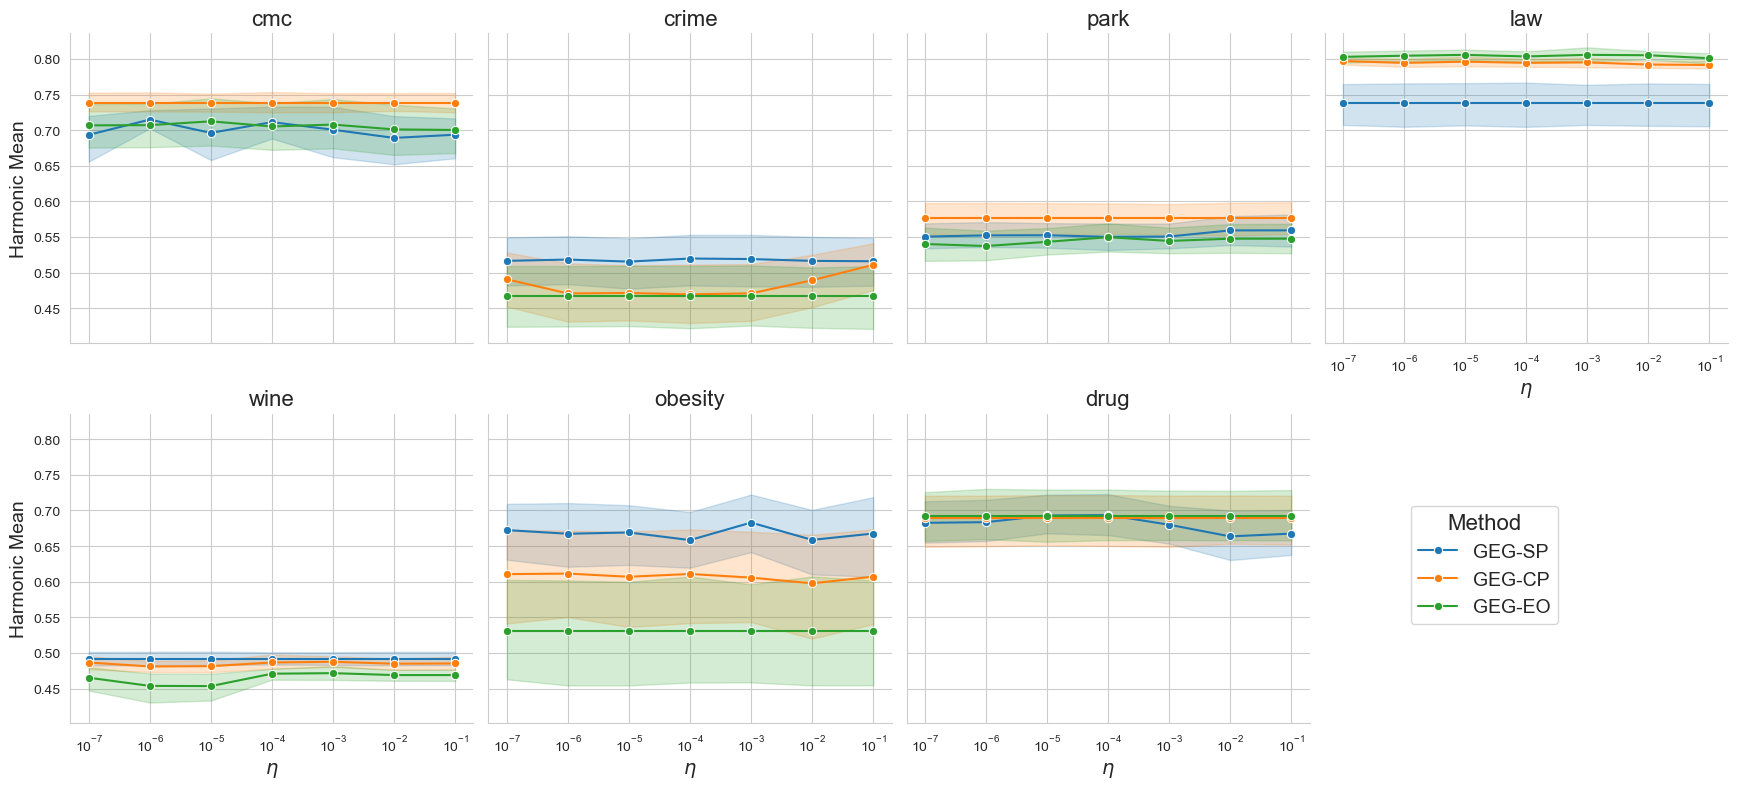

In [45]:



g = sns.FacetGrid(data, col="dataset", col_wrap=4, height=4)
g.map_dataframe(sns.lineplot, y="harmonic_mean", x="ratio_bound_slack", hue="constraint", marker="o")

g.set(xscale="log")


g.set_axis_labels("$\\eta$", "Harmonic Mean", size=14)
g.set_titles(col_template="{col_name}", size=16)
g.add_legend(
    title="Constraint", loc="lower right", prop={"size": 14}, bbox_to_anchor=(0.9, 0.2),frameon=True)
# position the legend near the last plot
# sns.move_legend(g, "lower right", bbox_to_anchor=(0.9, 0.2))
g.legend.set_title("Method", prop={"size": 16})
# plt.ticklabel_format(style="sci", axis="x", scilimits=(0, 0))
plt.tight_layout()
plt.savefig("imgs/harmonic_mean_rq5_ratio_bound_slack.pdf", bbox_inches="tight")
plt.show()